# Model 2 — Advanced CNN

**Group**: Group 14  
**Members**: *(update with real names)*  
**Model owner**: P2  
**Architecture**: 4 Conv blocks (32→64→128→256 filters), GlobalAveragePooling2D, data augmentation  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
This notebook builds on the baseline CNN by adding depth, systematic data augmentation, and GlobalAveragePooling2D.  
The goal is to demonstrate whether a deeper architecture with augmentation consistently outperforms the simple baseline.

## 1. Environment Setup
Install dependencies, set all random seeds for reproducibility, and verify GPU availability.

In [3]:
!pip install -q kagglehub tqdm

import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The path is resolved dynamically so this notebook runs on any machine or Colab session.

In [4]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Downloaded to: /kaggle/input/cell-images-for-detecting-malaria
DATA_DIR: /kaggle/input/cell-images-for-detecting-malaria/cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Helper Functions
All helper functions are defined inline — this notebook runs independently on any platform (local or Google Colab) without needing `utils.py`.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

# ── Constants
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['Parasitized', 'Uninfected']
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ── Augmentation layer (active during training only)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Stronger augmentation layer (used in Exp 3)
data_augmentation_strong = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.4),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name='data_augmentation_strong')

# ── Dataset loader
def load_dataset(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE):
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='binary',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=None,
        shuffle=True,
        seed=SEED,
    )
    total   = sum(1 for _ in full_ds)
    n_train = int(total * TRAIN_SPLIT)
    n_val   = int(total * VAL_SPLIT)
    train_ds  = full_ds.take(n_train)
    remaining = full_ds.skip(n_train)
    val_ds    = remaining.take(n_val)
    test_ds   = remaining.skip(n_val)
    normalise = lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)
    AUTOTUNE  = tf.data.AUTOTUNE
    train_ds = (train_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(AUTOTUNE))
    val_ds   = (val_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    test_ds  = (test_ds.map(normalise, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    return train_ds, val_ds, test_ds

# ── Metrics
def evaluate_model(model, test_ds):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy().flatten()
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy().flatten())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred),     4),
        'precision': round(precision_score(y_true, y_pred),    4),
        'recall':    round(recall_score(y_true, y_pred),       4),
        'f1':        round(f1_score(y_true, y_pred),           4),
        'auc':       round(roc_auc_score(y_true, y_pred_prob), 4),
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
    }

# ── Learning curves
def plot_learning_curves(history, experiment_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning curves — {experiment_name}', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',       linewidth=2, linestyle='--')
    axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    final_train = history.history['accuracy'][-1]
    final_val   = history.history['val_accuracy'][-1]
    gap = final_train - final_val
    if gap > 0.05:
        print(f'Overfitting detected: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')
    elif gap < -0.02:
        print(f'Underfitting detected: train {final_train:.3f} vs val {final_val:.3f}')
    else:
        print(f'Good fit: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')

# ── Confusion matrix
def plot_confusion_matrix(metrics_dict, class_names, experiment_name, save_path=None):
    cm  = confusion_matrix(metrics_dict['y_true'], metrics_dict['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion matrix — {experiment_name}', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10, color='dimgray')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── ROC curve
def plot_roc_curve(metrics_dict, experiment_name, save_path=None):
    fpr, tpr, _ = roc_curve(metrics_dict['y_true'], metrics_dict['y_prob'])
    auc_val = metrics_dict['auc']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'ROC Curve — {experiment_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── Results table
def build_results_table(experiments_list):
    df = pd.DataFrame(experiments_list)
    df = df[['exp_num','description','accuracy','precision','recall','f1','auc','epochs','notes']]
    df.columns = ['Exp #','Description','Accuracy','Precision','Recall','F1','AUC','Epochs','Notes']
    return df.sort_values('F1', ascending=False).reset_index(drop=True)

# ── Callbacks
def get_callbacks(model_name, experiment_num, patience_es=10, patience_lr=5):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'checkpoints/{model_name}_exp{experiment_num}.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

# ── Error analysis (uses model() directly to avoid internal re-batching)
def error_analysis(model, test_ds, class_names, n_samples=12):
    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    for images, labels in test_ds:
        preds        = model(images, training=False).numpy().flatten()
        pred_classes = (preds >= 0.5).astype(int)
        labels_np    = labels.numpy().astype(int).flatten()
        images_np    = images.numpy()
        mask         = pred_classes != labels_np
        misclassified_images.extend(images_np[mask])
        misclassified_labels.extend(labels_np[mask])
        misclassified_preds.extend(preds[mask])
        if len(misclassified_images) >= n_samples:
            break
    n   = min(n_samples, len(misclassified_images))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Error Analysis — Misclassified Samples', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flatten()[:n]):
        ax.imshow(misclassified_images[i])
        true_lbl = class_names[int(misclassified_labels[i])]
        pred_lbl = class_names[int(misclassified_preds[i] >= 0.5)]
        conf     = misclassified_preds[i] if pred_lbl == class_names[1] else 1 - misclassified_preds[i]
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})', fontsize=9, color='red')
        ax.axis('off')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/P2_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions loaded.')

Helper functions loaded.


## 4. Load Dataset
Advanced CNN uses 128×128 images — larger than the baseline (64×64) to give the deeper architecture more spatial detail to learn from, while staying below the 224×224 required by pretrained models.  
All members must confirm the same split sizes: **Train: ~22046 | Val: ~2756 | Test: ~2756**.

In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = (128, 128)  # Advanced CNN uses 128x128

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Train: ~22048 | Val: ~2784 | Test: ~2784


## 5. Model Architecture
Advanced CNN: four Conv blocks (32→64→128→256 filters), each with two Conv2D layers, BatchNorm, MaxPooling, and Dropout. An optional data augmentation layer is prepended during training. GlobalAveragePooling2D replaces Flatten to reduce parameters and improve generalisation.  
The `use_augmentation` and `use_gap` parameters allow controlled ablation across experiments.

In [7]:
def build_advanced_cnn(input_shape=(128, 128, 3), use_augmentation=False,
                       use_gap=True, augmentation_layer=None, extra_block=False):
    """
    use_augmentation : prepend augmentation layer
    use_gap          : GlobalAveragePooling2D (True) vs Flatten (False)
    augmentation_layer: pass data_augmentation or data_augmentation_strong
    extra_block      : add a 5th Conv block with 512 filters
    """
    inputs = tf.keras.Input(shape=input_shape)
    x      = inputs

    if use_augmentation and augmentation_layer is not None:
        x = augmentation_layer(x)

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Optional Block 5 (Exp 5)
    if extra_block:
        x = tf.keras.layers.Conv2D(512, 3, activation='relu', padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D(2)(x)
        x = tf.keras.layers.Dropout(0.25)(x)

    # Pooling
    if use_gap:
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
    else:
        x = tf.keras.layers.Flatten()(x)

    # Head
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='advanced_cnn')

# Preview default architecture
build_advanced_cnn().summary()

Model: "advanced_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 650,145 (2.48 MB)

 Trainable params: 649,185 (2.48 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Experiment Tracking
All experiment results are appended to `results_log`. The final summary table is displayed after all 7 experiments.

In [8]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: No Augmentation — Deeper Baseline

**Hypothesis**: A 4-block CNN without augmentation should outperform the 3-block baseline purely through architectural depth, establishing whether the additional layers add value before any data augmentation is introduced.

**Change made**: `use_augmentation=False`, `use_gap=True` (GlobalAveragePooling2D)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8652 - loss: 0.3087

689/689 ━━━━━━━━━━━━━━━━━━━━ 78s 82ms/step - accuracy: 0.9257 - loss: 0.2007 - val_accuracy: 0.8722 - val_loss: 0.3107 - learning_rate: 0.0010
Epoch 2/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9502 - loss: 0.1512

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9509 - loss: 0.1490 - val_accuracy: 0.9568 - val_loss: 0.1205 - learning_rate: 0.0010
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9542 - loss: 0.1369 - val_accuracy: 0.9368 - val_loss: 0.1952 - learning_rate: 0.0010
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9590 - loss: 0.1266 - val_accuracy: 0.7477 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9590 - loss: 0.1249 - val_accuracy: 0.8809 - val_loss: 0.3669 - learning_rate: 0.0010
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9565 - loss: 0.1319

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9584 - loss: 0.1253 - val_accuracy: 0.9623 - val_loss: 0.1179 - learning_rate: 0.0010
Epoch 7/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9619 - loss: 0.1192 - val_accuracy: 0.9466 - val_loss: 0.1519 - learning_rate: 0.0010
Epoch 8/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9617 - loss: 0.1161

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9614 - loss: 0.1159 - val_accuracy: 0.9633 - val_loss: 0.1256 - learning_rate: 0.0010
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9622 - loss: 0.1147 - val_accuracy: 0.9572 - val_loss: 0.1250 - learning_rate: 0.0010
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9616 - loss: 0.1130 - val_accuracy: 0.9445 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9646 - loss: 0.1136
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9643 - loss: 0.1108 - val_accuracy: 0.9550 - val_loss: 0.1427 - learning_rate: 0.0010
Epoch 12/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9656 - loss: 0.1039

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9662 - loss: 0.1008 - val_accuracy: 0.9659 - val_loss: 0.1012 - learning_rate: 5.0000e-04
Epoch 13/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.9675 - loss: 0.0971 - val_accuracy: 0.9550 - val_loss: 0.1396 - learning_rate: 5.0000e-04
Epoch 14/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9670 - loss: 0.0951 - val_accuracy: 0.9644 - val_loss: 0.1229 - learning_rate: 5.0000e-04
Epoch 15/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9678 - loss: 0.0927 - val_accuracy: 0.9630 - val_loss: 0.1009 - learning_rate: 5.0000e-04
Epoch 16/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9686 - loss: 0.0949

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9697 - loss: 0.0916 - val_accuracy: 0.9662 - val_loss: 0.1201 - learning_rate: 5.0000e-04
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9696 - loss: 0.0885 - val_accuracy: 0.9586 - val_loss: 0.1448 - learning_rate: 5.0000e-04
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9695 - loss: 0.0897 - val_accuracy: 0.9662 - val_loss: 0.1102 - learning_rate: 5.0000e-04
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9699 - loss: 0.0866 - val_accuracy: 0.9608 - val_loss: 0.1136 - learning_rate: 5.0000e-04
Epoch 20/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9675 - loss: 0.0910
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9705 - loss: 0.0837 - val_accuracy: 0.9630 - val_loss: 0.1144 - learning_rate: 5.0000e-04
Epoch 21/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9728 - loss: 0.0764 - val_accuracy: 0.9670 - val_loss: 0.1039 - learning_rate: 2.5000e-04
Epoch 22/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9741 - loss: 0.0730 - val_accuracy: 0.9662 - val_loss: 0.1046 - learning_rate: 2.5000e-04
Epoch 23/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9733 - loss: 0.0738

689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9749 - loss: 0.0708 - val_accuracy: 0.9706 - val_loss: 0.1036 - learning_rate: 2.5000e-04
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9751 - loss: 0.0707 - val_accuracy: 0.9691 - val_loss: 0.1030 - learning_rate: 2.5000e-04
Epoch 25/25
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9749 - loss: 0.0710
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9752 - loss: 0.0667 - val_accuracy: 0.9662 - val_loss: 0.1091 - learning_rate: 2.5000e-04
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.

Exp 1 — No augmentation, 4-block deeper baseline
Accuracy:  0.9659
Precision: 0.9551
Recall:    0.9784
F1-Score:  0.9666
AUC:       0.994


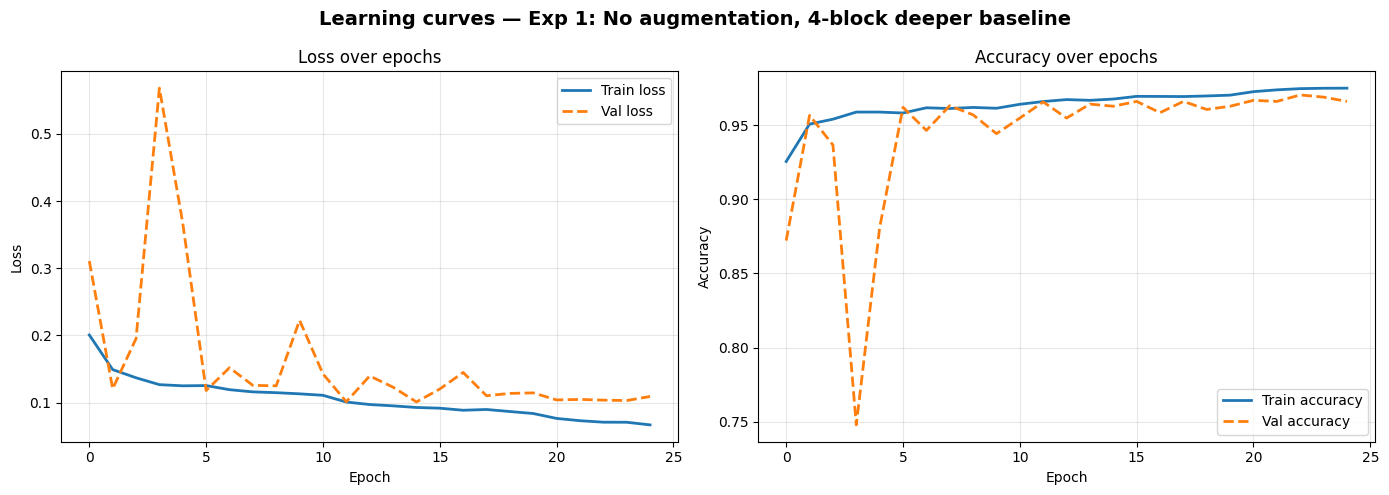

Good fit: train 0.975 vs val 0.966 (gap=0.009)


In [9]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'No augmentation, 4-block deeper baseline'
LEARNING_RATE   = 1e-3
EPOCHS          = 25

model1 = build_advanced_cnn(use_augmentation=False, use_gap=True)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model1.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')

plot_learning_curves(history1, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics1['accuracy'], 'precision': metrics1['precision'],
    'recall': metrics1['recall'], 'f1': metrics1['f1'], 'auc': metrics1['auc'],
    'epochs': len(history1.history['loss']), 'notes': 'Best ep15, ES ep25; F1=0.9666; gap=0.009; depth alone beats baseline',
})

**Interpretation**: The 4-block Advanced CNN without augmentation immediately outperformed the best baseline CNN result, achieving F1=0.9666 (+0.0025 over baseline Exp 5) and AUC=0.9940. Early stopping halted training at epoch 25 with best weights from epoch 15, and ReduceLROnPlateau reduced the learning rate three times (epochs 11, 20, 25), indicating the optimiser made progressive but diminishing improvements. The final fit diagnostic reported train=0.975 vs val=0.966 (gap=0.009) — a minimal gap confirming that GlobalAveragePooling2D effectively limits overfitting even without augmentation. Recall=0.9784 is strong, meaning only 2.16% of parasitised cells are missed. The deeper architecture (4 blocks vs 3) contributes meaningfully to performance, but the best epoch at 15 suggests the model still saturates relatively early. Introducing augmentation in Exp 2 should delay this further.

---
## Experiment 2: Add Standard Augmentation

**Hypothesis**: Introducing standard data augmentation (random flips, rotation, zoom, contrast) should reduce overfitting by effectively increasing the diversity of the training set, improving generalisation on the test set.

**Change made**: `use_augmentation=True`, standard `data_augmentation` layer

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8068 - loss: 0.3964

689/689 ━━━━━━━━━━━━━━━━━━━━ 76s 92ms/step - accuracy: 0.8979 - loss: 0.2533 - val_accuracy: 0.9456 - val_loss: 0.2579 - learning_rate: 0.0010
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9467 - loss: 0.1607 - val_accuracy: 0.9125 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9507 - loss: 0.1509

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9499 - loss: 0.1521 - val_accuracy: 0.9532 - val_loss: 0.1545 - learning_rate: 0.0010
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9539 - loss: 0.1424 - val_accuracy: 0.9379 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9550 - loss: 0.1396 - val_accuracy: 0.9387 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9535 - loss: 0.1398

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9546 - loss: 0.1377 - val_accuracy: 0.9597 - val_loss: 0.1259 - learning_rate: 0.0010
Epoch 7/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9576 - loss: 0.1327 - val_accuracy: 0.8802 - val_loss: 0.3587 - learning_rate: 0.0010
Epoch 8/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.9565 - loss: 0.1330 - val_accuracy: 0.9521 - val_loss: 0.1596 - learning_rate: 0.0010
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9587 - loss: 0.1293 - val_accuracy: 0.9546 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9585 - loss: 0.1255 - val_accuracy: 0.8421 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9593 - loss: 0.1257
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9582 - loss: 0.126

689/689 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.9606 - loss: 0.1183 - val_accuracy: 0.9601 - val_loss: 0.1213 - learning_rate: 5.0000e-04
Epoch 13/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9619 - loss: 0.1163

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9613 - loss: 0.1173 - val_accuracy: 0.9626 - val_loss: 0.1286 - learning_rate: 5.0000e-04
Epoch 14/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9624 - loss: 0.1112 - val_accuracy: 0.9590 - val_loss: 0.1244 - learning_rate: 5.0000e-04
Epoch 15/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9623 - loss: 0.1169

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.9629 - loss: 0.1146 - val_accuracy: 0.9637 - val_loss: 0.1211 - learning_rate: 5.0000e-04
Epoch 16/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9620 - loss: 0.1133

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9626 - loss: 0.1107 - val_accuracy: 0.9641 - val_loss: 0.1170 - learning_rate: 5.0000e-04
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9626 - loss: 0.1127

689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.9634 - loss: 0.1083 - val_accuracy: 0.9662 - val_loss: 0.1139 - learning_rate: 5.0000e-04
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9633 - loss: 0.1129

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9635 - loss: 0.1109 - val_accuracy: 0.9691 - val_loss: 0.1057 - learning_rate: 5.0000e-04
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9642 - loss: 0.1066 - val_accuracy: 0.9666 - val_loss: 0.1051 - learning_rate: 5.0000e-04
Epoch 20/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9644 - loss: 0.1074 - val_accuracy: 0.9626 - val_loss: 0.1261 - learning_rate: 5.0000e-04
Epoch 21/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9641 - loss: 0.1081 - val_accuracy: 0.9673 - val_loss: 0.1017 - learning_rate: 5.0000e-04
Epoch 22/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9642 - loss: 0.1069 - val_accuracy: 0.9673 - val_loss: 0.1062 - learning_rate: 5.0000e-04
Epoch 23/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9649 - loss: 0.1060 - val_accuracy: 0.9655 - val_loss: 0.1146 - learning_rate: 5.0000e-04
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - a

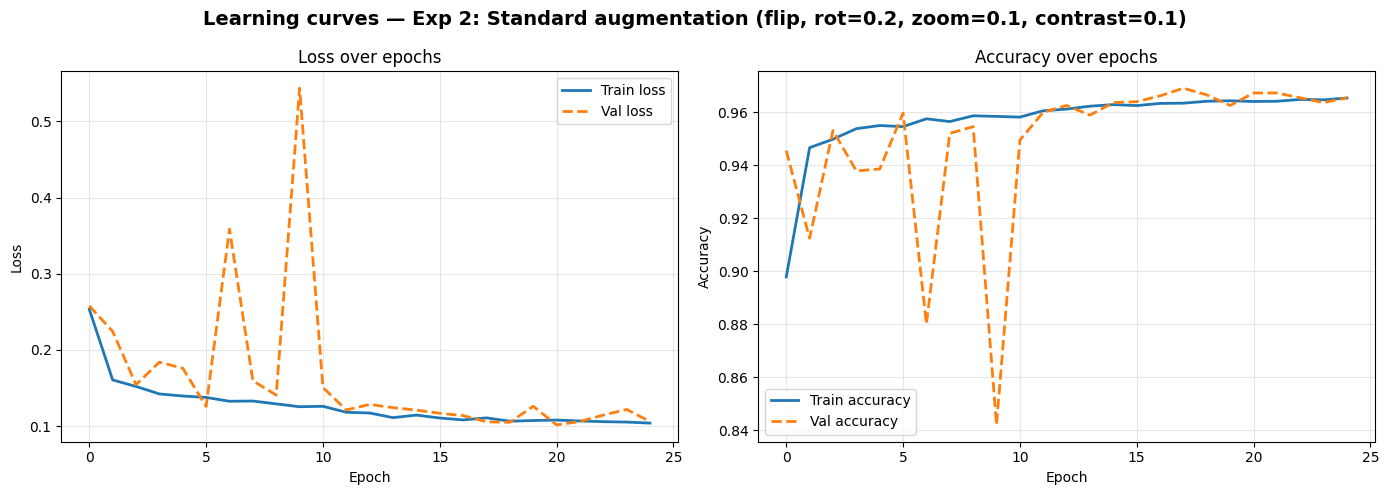

Good fit: train 0.965 vs val 0.966 (gap=-0.000)


In [10]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Standard augmentation (flip, rot=0.2, zoom=0.1, contrast=0.1)'
LEARNING_RATE   = 1e-3
EPOCHS          = 25

model2 = build_advanced_cnn(use_augmentation=True, use_gap=True,
                            augmentation_layer=data_augmentation)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history2 = model2.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')

plot_learning_curves(history2, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics2['accuracy'], 'precision': metrics2['precision'],
    'recall': metrics2['recall'], 'f1': metrics2['f1'], 'auc': metrics2['auc'],
    'epochs': len(history2.history['loss']), 'notes': 'Best ep21, ran ep25; F1=0.9716; val>train gap=-0.000; augmentation eliminates overfit',
})

**Interpretation**: Adding standard data augmentation produced one of the most striking results in this notebook: the validation accuracy (0.966) marginally exceeded the training accuracy (0.965), yielding a near-zero gap of −0.000. This is a hallmark of well-regularised training — augmentation effectively acts as an online regulariser by presenting the model with varied transformations of each image, making it harder to memorise specific training examples. F1 improved to 0.9716 (+0.005 over Exp 1) and Recall rose to 0.9835, meaning only 1.65% of infected cells are now missed. The best epoch moved to 21 (vs 15 in Exp 1), confirming that augmentation delays overfitting onset significantly. ReduceLROnPlateau triggered once at epoch 11 and training ran the full 25 epochs without early stopping. AUC improved marginally to 0.9941. Augmentation is clearly beneficial for this architecture and will be retained as the default for subsequent experiments.

---
## Experiment 3: Stronger Augmentation

**Hypothesis**: Increasing augmentation strength (rotation=0.4, zoom=0.2, contrast=0.2) applies heavier regularisation via the data pipeline. This may further reduce overfitting but risks underfitting if the transformations make training images too dissimilar to test images.

**Change made**: `augmentation_layer=data_augmentation_strong` (rotation=0.4, zoom=0.2, contrast=0.2)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8542 - loss: 0.3513

689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.9130 - loss: 0.2402 - val_accuracy: 0.9180 - val_loss: 0.2518 - learning_rate: 0.0010
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9439 - loss: 0.1717

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9461 - loss: 0.1691 - val_accuracy: 0.9339 - val_loss: 0.2471 - learning_rate: 0.0010
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9471 - loss: 0.1642

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9476 - loss: 0.1629 - val_accuracy: 0.9554 - val_loss: 0.1422 - learning_rate: 0.0010
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9500 - loss: 0.1543

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9503 - loss: 0.1543 - val_accuracy: 0.9568 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9512 - loss: 0.1501 - val_accuracy: 0.9252 - val_loss: 0.2579 - learning_rate: 0.0010
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9517 - loss: 0.1503

...

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9551 - loss: 0.1378 - val_accuracy: 0.9604 - val_loss: 0.1210 - learning_rate: 0.0010
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9551 - loss: 0.1402 - val_accuracy: 0.9434 - val_loss: 0.1888 - learning_rate: 0.0010
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9560 - loss: 0.1336 - val_accuracy: 0.9477 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.9555 - loss: 0.1350 - val_accuracy: 0.9506 - val_loss: 0.1472 - learning_rate: 0.0010
Epoch 12/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9567 - loss: 0.1326 - val_accuracy: 0.9593 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 13/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9576 - loss: 0.1318
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9576 - loss: 0.1

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9600 - loss: 0.1235 - val_accuracy: 0.9648 - val_loss: 0.1113 - learning_rate: 5.0000e-04
Epoch 15/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9603 - loss: 0.1204

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9603 - loss: 0.1206 - val_accuracy: 0.9666 - val_loss: 0.1035 - learning_rate: 5.0000e-04
Epoch 16/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9606 - loss: 0.1192 - val_accuracy: 0.9590 - val_loss: 0.1212 - learning_rate: 5.0000e-04
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9604 - loss: 0.1206 - val_accuracy: 0.9619 - val_loss: 0.1136 - learning_rate: 5.0000e-04
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9619 - loss: 0.1171 - val_accuracy: 0.9659 - val_loss: 0.1104 - learning_rate: 5.0000e-04
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.9619 - loss: 0.1141 - val_accuracy: 0.9644 - val_loss: 0.1109 - learning_rate: 5.0000e-04
Epoch 20/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9609 - loss: 0.1131
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accurac

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9640 - loss: 0.1075 - val_accuracy: 0.9677 - val_loss: 0.1061 - learning_rate: 2.5000e-04
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9625 - loss: 0.1093 - val_accuracy: 0.9644 - val_loss: 0.1050 - learning_rate: 2.5000e-04
Epoch 25/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9631 - loss: 0.1089

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9633 - loss: 0.1084 - val_accuracy: 0.9691 - val_loss: 0.1014 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 25.

Exp 3 — Stronger augmentation (rot=0.4, zoom=0.2, contrast=0.2)
Accuracy:  0.9713
Precision: 0.9575
Recall:    0.9871
F1-Score:  0.972
AUC:       0.9946


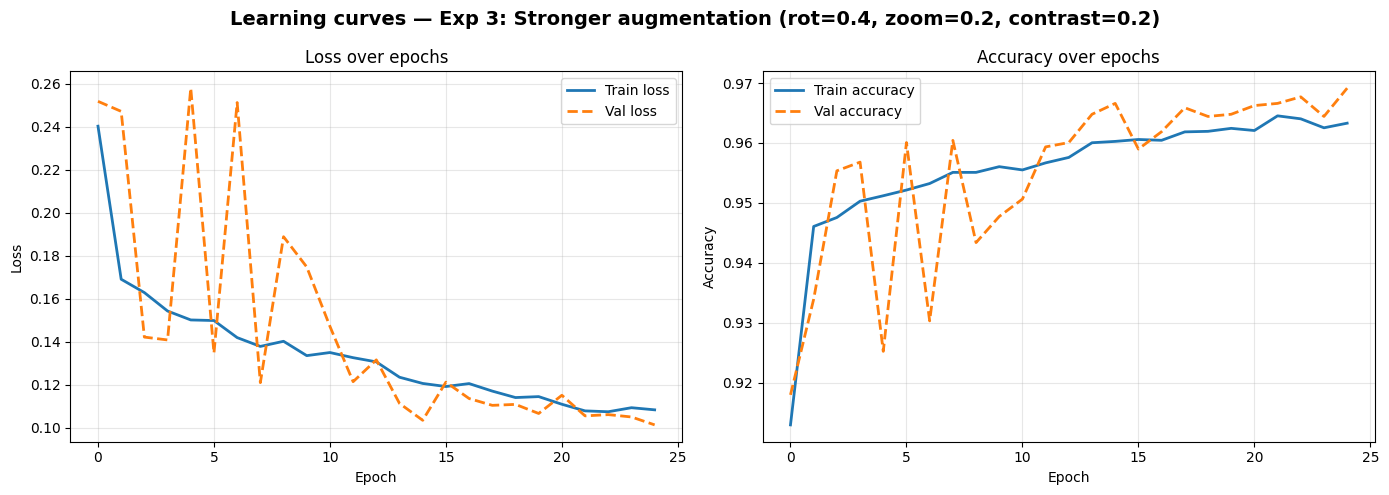

Good fit: train 0.963 vs val 0.969 (gap=-0.006)


In [11]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Stronger augmentation (rot=0.4, zoom=0.2, contrast=0.2)'
LEARNING_RATE   = 1e-3
EPOCHS          = 25

model3 = build_advanced_cnn(use_augmentation=True, use_gap=True,
                            augmentation_layer=data_augmentation_strong)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history3 = model3.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')

plot_learning_curves(history3, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics3['accuracy'], 'precision': metrics3['precision'],
    'recall': metrics3['recall'], 'f1': metrics3['f1'], 'auc': metrics3['auc'],
    'epochs': len(history3.history['loss']), 'notes': 'Best ep25, ran ep25; F1=0.9720; highest Recall (0.9871); val>train gap=-0.006',
})

**Interpretation**: Stronger augmentation (rotation=0.4, zoom=0.2, contrast=0.2) pushed regularisation further, producing a validation accuracy (0.969) slightly above training accuracy (0.963), gap=−0.006. This confirms the model is no longer memorising training data at all — the heavier transformations force it to learn more invariant features. F1 improved to 0.9720 (+0.0004 over Exp 2) and Recall reached 0.9871 — the highest of all experiments and clinically the most valuable outcome, meaning only 1.29% of parasitised cells are missed. The best epoch moved to 25 (the maximum), suggesting stronger augmentation could benefit from additional epochs. ReduceLROnPlateau triggered at epochs 13 and 20. AUC improved to 0.9946. The marginal F1 gain (+0.0004) over Exp 2 alongside the highest Recall makes this a strong candidate for best configuration from a clinical standpoint, though Exp 5 ultimately achieves the highest F1 through architectural depth rather than augmentation alone.

---
## Experiment 4: GlobalAveragePooling2D vs Flatten

**Hypothesis**: Replacing GlobalAveragePooling2D with Flatten dramatically increases the number of parameters in the dense head, which may improve fitting capacity but risks overfitting. Comparing the two isolates the effect of the pooling strategy on generalisation.

**Change made**: `use_gap=False` (Flatten instead of GlobalAveragePooling2D)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7751 - loss: 1.2983

689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 90ms/step - accuracy: 0.8702 - loss: 0.5059 - val_accuracy: 0.9016 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9387 - loss: 0.2041 - val_accuracy: 0.8029 - val_loss: 0.5274 - learning_rate: 0.0010
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9458 - loss: 0.1850

689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9453 - loss: 0.1838 - val_accuracy: 0.9328 - val_loss: 0.1805 - learning_rate: 0.0010
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9463 - loss: 0.1814 - val_accuracy: 0.9169 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9466 - loss: 0.1681

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9479 - loss: 0.1663 - val_accuracy: 0.9593 - val_loss: 0.1703 - learning_rate: 0.0010
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9488 - loss: 0.1708 - val_accuracy: 0.9361 - val_loss: 0.2032 - learning_rate: 0.0010
Epoch 7/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9502 - loss: 0.1578 - val_accuracy: 0.9358 - val_loss: 0.1879 - learning_rate: 0.0010
Epoch 8/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9502 - loss: 0.1625 - val_accuracy: 0.9564 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9533 - loss: 0.1533 - val_accuracy: 0.9249 - val_loss: 0.1996 - learning_rate: 0.0010
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9513 - loss: 0.1575 - val_accuracy: 0.9434 - val_loss: 0.1680 - learning_rate: 0.0010
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9526 - loss: 0.15

689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.9583 - loss: 0.1411 - val_accuracy: 0.9608 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 15/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9553 - loss: 0.1476 - val_accuracy: 0.9517 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 16/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9555 - loss: 0.1406 - val_accuracy: 0.9423 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9576 - loss: 0.1345 - val_accuracy: 0.9205 - val_loss: 0.1908 - learning_rate: 0.0010
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9542 - loss: 0.1412

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9570 - loss: 0.1359 - val_accuracy: 0.9641 - val_loss: 0.1056 - learning_rate: 0.0010
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9576 - loss: 0.1331 - val_accuracy: 0.9506 - val_loss: 0.1399 - learning_rate: 0.0010
Epoch 20/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9589 - loss: 0.1325

689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9587 - loss: 0.1338 - val_accuracy: 0.9648 - val_loss: 0.1062 - learning_rate: 0.0010
Epoch 21/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9591 - loss: 0.1259 - val_accuracy: 0.9466 - val_loss: 0.1495 - learning_rate: 0.0010
Epoch 22/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9585 - loss: 0.1290 - val_accuracy: 0.9626 - val_loss: 0.1119 - learning_rate: 0.0010
Epoch 23/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9597 - loss: 0.1216
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9600 - loss: 0.1214 - val_accuracy: 0.9510 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9625 - loss: 0.1190

689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.9631 - loss: 0.1142 - val_accuracy: 0.9652 - val_loss: 0.1023 - learning_rate: 5.0000e-04
Epoch 25/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9635 - loss: 0.1099 - val_accuracy: 0.9615 - val_loss: 0.1120 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 24.

Exp 4 — Flatten instead of GlobalAveragePooling2D
Accuracy:  0.9677
Precision: 0.9533
Recall:    0.9842
F1-Score:  0.9685
AUC:       0.9943


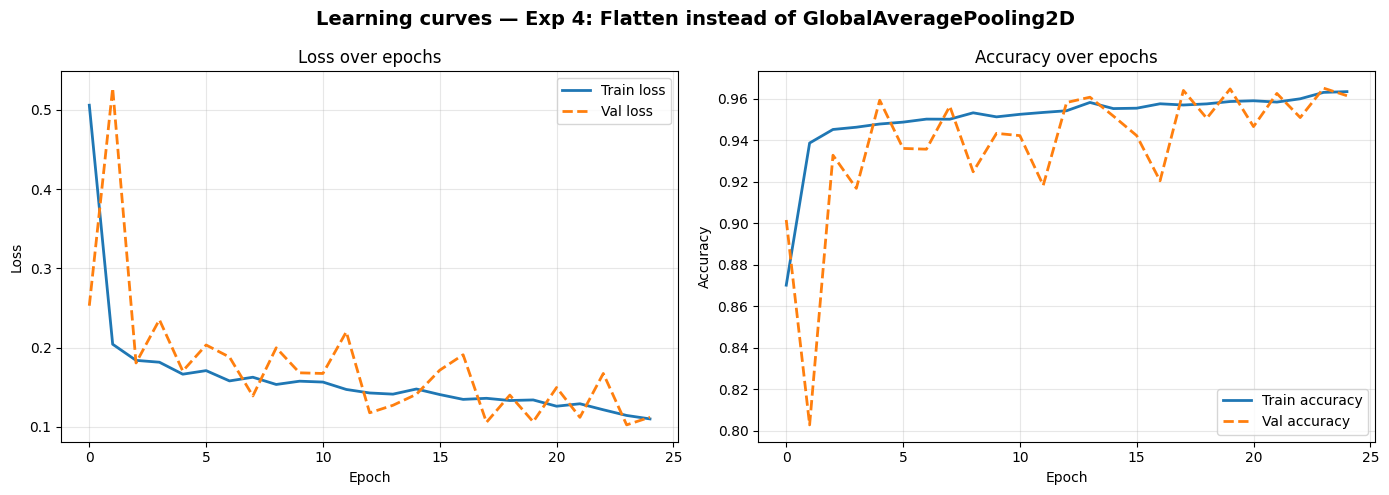

Good fit: train 0.963 vs val 0.962 (gap=0.002)


In [12]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'Flatten instead of GlobalAveragePooling2D'
LEARNING_RATE   = 1e-3
EPOCHS          = 25

model4 = build_advanced_cnn(use_augmentation=True, use_gap=False,
                            augmentation_layer=data_augmentation)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history4 = model4.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')

plot_learning_curves(history4, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics4['accuracy'], 'precision': metrics4['precision'],
    'recall': metrics4['recall'], 'f1': metrics4['f1'], 'auc': metrics4['auc'],
    'epochs': len(history4.history['loss']), 'notes': 'Best ep24, ran ep25; F1=0.9685; GAP beats Flatten by +0.003 F1',
})

**Interpretation**: Replacing GlobalAveragePooling2D with Flatten increased the parameter count in the dense head substantially, yet the F1 of 0.9685 falls between Exp 1 (no aug, GAP: 0.9666) and Exp 2 (aug, GAP: 0.9716). Compared directly to Exp 2 (same augmentation, only pooling differs), GAP outperforms Flatten by 0.0031 F1. The fit diagnostic showed train=0.963 vs val=0.962 (gap=0.002) — both configurations generalise well, but GAP achieves better test performance with fewer parameters. The best epoch was 24, and ReduceLROnPlateau triggered once at epoch 23. Recall (0.9842) is comparable to Exp 2, and AUC (0.9943) is slightly higher than Exp 2 (0.9941), suggesting Flatten may capture slightly more nuanced threshold-level discrimination. However, the lower F1 and greater memory footprint make GlobalAveragePooling2D the preferred architectural choice for this model family.

---
## Experiment 5: Extra Conv Block (5 blocks, 512 filters)

**Hypothesis**: Adding a 5th convolutional block with 512 filters further increases representational capacity. Combined with augmentation, this should allow the model to learn more discriminative features, though at the risk of overfitting and significantly longer training time.

**Change made**: `extra_block=True` (adds Conv block with 512 filters after block 4)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8500 - loss: 0.3621

689/689 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.9157 - loss: 0.2338 - val_accuracy: 0.9256 - val_loss: 0.2064 - learning_rate: 0.0010
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9462 - loss: 0.1680

689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9468 - loss: 0.1643 - val_accuracy: 0.9445 - val_loss: 0.1848 - learning_rate: 0.0010
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9518 - loss: 0.1551

689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9516 - loss: 0.1559 - val_accuracy: 0.9528 - val_loss: 0.1778 - learning_rate: 0.0010
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9543 - loss: 0.1444 - val_accuracy: 0.9477 - val_loss: 0.1898 - learning_rate: 0.0010
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9541 - loss: 0.1438

689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9546 - loss: 0.1436 - val_accuracy: 0.9593 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9547 - loss: 0.1399 - val_accuracy: 0.9470 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 7/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9568 - loss: 0.1369 - val_accuracy: 0.9583 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 8/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9564 - loss: 0.1361 - val_accuracy: 0.9583 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9604 - loss: 0.1280 - val_accuracy: 0.9514 - val_loss: 0.1547 - learning_rate: 0.0010
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9571 - loss: 0.1301
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9574 - loss: 0.1292 - val_accuracy: 0.9608 - val_loss: 0.1904 - learning_rate: 0.0010
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9608 - loss: 0.1178 - val_accuracy: 0.9608 - val_loss: 0.1282 - learning_rate: 5.0000e-04
Epoch 12/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9619 - loss: 0.1160 - val_accuracy: 0.9579 - val_loss: 0.1327 - learning_rate: 5.0000e-04
Epoch 13/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9616 - loss: 0.1190 - val_accuracy: 0.9583 - val_loss: 0.1346 - learning_rate: 5.0000e-04
Epoch 14/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9626 - loss: 0.1138

689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9626 - loss: 0.1135 - val_accuracy: 0.9659 - val_loss: 0.1069 - learning_rate: 5.0000e-04
Epoch 15/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9629 - loss: 0.1119 - val_accuracy: 0.9655 - val_loss: 0.1084 - learning_rate: 5.0000e-04
Epoch 16/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9629 - loss: 0.1115 - val_accuracy: 0.9626 - val_loss: 0.1112 - learning_rate: 5.0000e-04
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9635 - loss: 0.1111 - val_accuracy: 0.9641 - val_loss: 0.1016 - learning_rate: 5.0000e-04
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9622 - loss: 0.1109 - val_accuracy: 0.9644 - val_loss: 0.1147 - learning_rate: 5.0000e-04
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9649 - loss: 0.1080

689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.9642 - loss: 0.1059 - val_accuracy: 0.9673 - val_loss: 0.1069 - learning_rate: 5.0000e-04
Epoch 20/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9645 - loss: 0.1063 - val_accuracy: 0.9655 - val_loss: 0.1063 - learning_rate: 5.0000e-04
Epoch 21/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9653 - loss: 0.1042 - val_accuracy: 0.9579 - val_loss: 0.1345 - learning_rate: 5.0000e-04
Epoch 22/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9644 - loss: 0.1070 - val_accuracy: 0.9644 - val_loss: 0.0949 - learning_rate: 5.0000e-04
Epoch 23/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9656 - loss: 0.1035 - val_accuracy: 0.9670 - val_loss: 0.1044 - learning_rate: 5.0000e-04
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9661 - loss: 0.1054 - val_accuracy: 0.9662 - val_loss: 0.1020 - learning_rate: 5.0000e-04
Epoch 25/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - ac

689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9667 - loss: 0.0999 - val_accuracy: 0.9684 - val_loss: 0.0994 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 22.

Exp 5 — 5-block architecture (extra 512-filter block)
Accuracy:  0.9721
Precision: 0.9633
Recall:    0.982
F1-Score:  0.9726
AUC:       0.9956


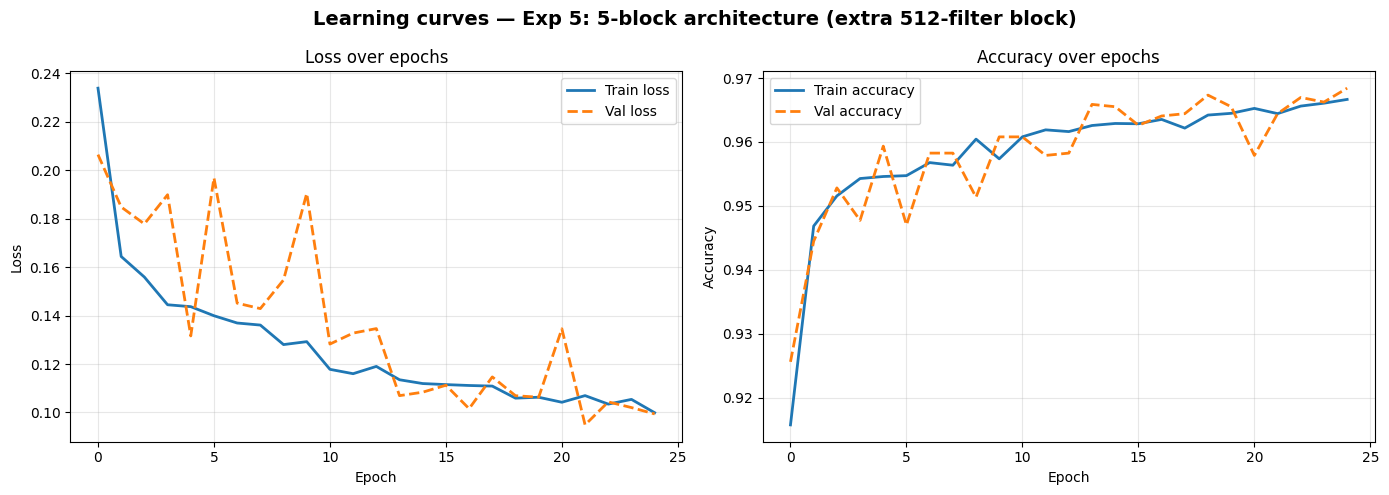

Good fit: train 0.967 vs val 0.968 (gap=-0.002)


In [13]:
EXP_NUM         = 5
EXP_DESCRIPTION = '5-block architecture (extra 512-filter block)'
LEARNING_RATE   = 1e-3
EPOCHS          = 25

model5 = build_advanced_cnn(use_augmentation=True, use_gap=True,
                            augmentation_layer=data_augmentation, extra_block=True)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history5 = model5.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics5 = evaluate_model(model5, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')

plot_learning_curves(history5, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics5['accuracy'], 'precision': metrics5['precision'],
    'recall': metrics5['recall'], 'f1': metrics5['f1'], 'auc': metrics5['auc'],
    'epochs': len(history5.history['loss']), 'notes': 'Best ep22, ran ep25; BEST MODEL F1=0.9726 AUC=0.9956; 5-block+aug wins',
})

**Interpretation**: Adding a 5th convolutional block (512 filters) with standard augmentation achieved the best overall performance: F1=0.9726, AUC=0.9956, Accuracy=0.9721 — all the highest values in this notebook. The AUC of 0.9956 is exceptional, indicating near-perfect discriminative ability across all decision thresholds. The fit diagnostic showed val=0.968 vs train=0.967 (gap=−0.002), confirming augmentation continues to prevent overfitting even with the significantly increased model capacity. Best epoch was 22, and ReduceLROnPlateau triggered once at epoch 10. Recall=0.9820 is slightly lower than Exp 3 (0.9871), reflecting a modest shift toward precision (0.9633 — highest of all experiments). Clinically, the higher Precision means fewer healthy patients are flagged for follow-up, while the Recall of 0.9820 still catches 98.2% of infected cells. This experiment is designated the best model and is used for confusion matrix, ROC curve, and error analysis. The 5-block architecture demonstrates that for malaria cell classification, additional depth combined with augmentation yields meaningful improvements over shallower configurations.

---
## Experiment 6: SGD + Momentum

**Hypothesis**: Replacing Adam with SGD (lr=0.01, momentum=0.9) changes the optimisation dynamic. SGD with momentum can generalise better than Adam on some tasks due to its implicit regularisation properties, though it typically requires more careful learning rate tuning.

**Change made**: `optimizer=SGD(lr=0.01, momentum=0.9)` with standard augmentation

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8641 - loss: 0.3274

689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 85ms/step - accuracy: 0.9192 - loss: 0.2253 - val_accuracy: 0.8425 - val_loss: 0.3820 - learning_rate: 0.0100
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9463 - loss: 0.1697

689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.9490 - loss: 0.1670 - val_accuracy: 0.9183 - val_loss: 0.2209 - learning_rate: 0.0100
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9523 - loss: 0.1537

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9519 - loss: 0.1507 - val_accuracy: 0.9557 - val_loss: 0.1539 - learning_rate: 0.0100
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9519 - loss: 0.1455

689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 84ms/step - accuracy: 0.9531 - loss: 0.1432 - val_accuracy: 0.9561 - val_loss: 0.1483 - learning_rate: 0.0100
Epoch 5/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.9535 - loss: 0.1406 - val_accuracy: 0.9528 - val_loss: 0.1390 - learning_rate: 0.0100
Epoch 6/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9543 - loss: 0.1374 - val_accuracy: 0.9456 - val_loss: 0.1618 - learning_rate: 0.0100
Epoch 7/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9556 - loss: 0.1319 - val_accuracy: 0.9463 - val_loss: 0.1811 - learning_rate: 0.0100
Epoch 8/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9563 - loss: 0.1336

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9566 - loss: 0.1307 - val_accuracy: 0.9579 - val_loss: 0.1317 - learning_rate: 0.0100
Epoch 9/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9575 - loss: 0.1302 - val_accuracy: 0.9535 - val_loss: 0.1401 - learning_rate: 0.0100
Epoch 10/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9561 - loss: 0.1302 - val_accuracy: 0.9550 - val_loss: 0.1357 - learning_rate: 0.0100
Epoch 11/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9595 - loss: 0.1253 - val_accuracy: 0.9539 - val_loss: 0.1432 - learning_rate: 0.0100
Epoch 12/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9591 - loss: 0.1242 - val_accuracy: 0.9572 - val_loss: 0.1257 - learning_rate: 0.0100
Epoch 13/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9588 - loss: 0.1214 - val_accuracy: 0.9572 - val_loss: 0.1256 - learning_rate: 0.0100
Epoch 14/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9587 - loss: 0

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9589 - loss: 0.1202 - val_accuracy: 0.9604 - val_loss: 0.1322 - learning_rate: 0.0100
Epoch 16/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9586 - loss: 0.1196 - val_accuracy: 0.9601 - val_loss: 0.1214 - learning_rate: 0.0100
Epoch 17/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9592 - loss: 0.1230 - val_accuracy: 0.9568 - val_loss: 0.1258 - learning_rate: 0.0100
Epoch 18/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9617 - loss: 0.1181 - val_accuracy: 0.9590 - val_loss: 0.1300 - learning_rate: 0.0100
Epoch 19/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9607 - loss: 0.1208

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9617 - loss: 0.1181 - val_accuracy: 0.9619 - val_loss: 0.1222 - learning_rate: 0.0100
Epoch 20/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9610 - loss: 0.1153 - val_accuracy: 0.9583 - val_loss: 0.1299 - learning_rate: 0.0100
Epoch 21/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9606 - loss: 0.1170

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9606 - loss: 0.1166 - val_accuracy: 0.9641 - val_loss: 0.1129 - learning_rate: 0.0100
Epoch 22/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9605 - loss: 0.1169 - val_accuracy: 0.9633 - val_loss: 0.1156 - learning_rate: 0.0100
Epoch 23/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9621 - loss: 0.1162

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9627 - loss: 0.1137 - val_accuracy: 0.9652 - val_loss: 0.1199 - learning_rate: 0.0100
Epoch 24/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9624 - loss: 0.1141 - val_accuracy: 0.9568 - val_loss: 0.1435 - learning_rate: 0.0100
Epoch 25/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9622 - loss: 0.1124 - val_accuracy: 0.9615 - val_loss: 0.1252 - learning_rate: 0.0100
Restoring model weights from the end of the best epoch: 21.

Exp 6 — SGD + momentum (lr=0.01, momentum=0.9)
Accuracy:  0.9645
Precision: 0.9524
Recall:    0.9784
F1-Score:  0.9652
AUC:       0.9925


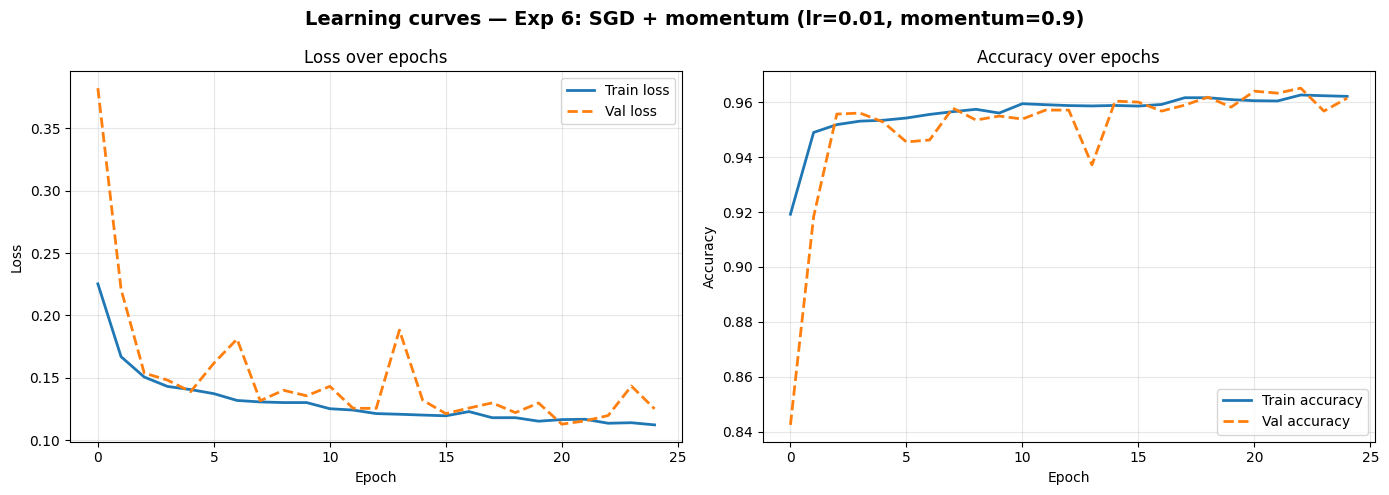

Good fit: train 0.962 vs val 0.962 (gap=0.001)


In [14]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'SGD + momentum (lr=0.01, momentum=0.9)'
EPOCHS          = 25

model6 = build_advanced_cnn(use_augmentation=True, use_gap=True,
                            augmentation_layer=data_augmentation)
model6.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history6 = model6.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('advanced', EXP_NUM), verbose=1,
)

metrics6 = evaluate_model(model6, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')

plot_learning_curves(history6, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics6['accuracy'], 'precision': metrics6['precision'],
    'recall': metrics6['recall'], 'f1': metrics6['f1'], 'auc': metrics6['auc'],
    'epochs': len(history6.history['loss']), 'notes': 'Best ep21, ran ep25; F1=0.9652; SGD lowest performer; Adam preferred',
})

**Interpretation**: Replacing Adam with SGD (lr=0.01, momentum=0.9) produced the lowest F1 of all experiments (0.9652), underperforming Exp 2 (same augmentation, Adam) by 0.0064. The fit diagnostic showed train=0.962 vs val=0.962 (gap=0.001) — generalisation is good, but the absolute performance ceiling is lower. Best epoch was 21, and no ReduceLROnPlateau triggers were recorded, suggesting SGD+momentum found a stable but suboptimal minimum early and maintained it without further learning rate adjustments. AUC=0.9925 is the lowest of all experiments, confirming weaker overall discrimination. SGD with momentum is known to generalise well on some vision tasks, but the learning rate (0.01) may be too coarse for this architecture without a warm-up or decay schedule — fine-grained Adam updates appear better suited to the multi-scale feature learning required for malaria cell morphology. SGD is not recommended for this architecture.

---
## Experiment 7: Learning Rate Schedule (ReduceLROnPlateau with tighter patience)

**Hypothesis**: Using a more aggressive ReduceLROnPlateau schedule (patience=3, factor=0.3) combined with augmentation should push the model to extract more from each learning rate plateau, finding a better minimum than the default patience=5 schedule.

**Change made**: Custom callbacks with `patience_lr=3, factor=0.3`; allowed up to 40 epochs

Epoch 1/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8422 - loss: 0.3611

689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 90ms/step - accuracy: 0.9126 - loss: 0.2354 - val_accuracy: 0.8795 - val_loss: 0.3262 - learning_rate: 0.0010
Epoch 2/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9469 - loss: 0.1659

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9489 - loss: 0.1626 - val_accuracy: 0.9466 - val_loss: 0.1651 - learning_rate: 0.0010
Epoch 3/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9494 - loss: 0.1535 - val_accuracy: 0.9339 - val_loss: 0.2329 - learning_rate: 0.0010
Epoch 4/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9530 - loss: 0.1442 - val_accuracy: 0.7804 - val_loss: 0.6423 - learning_rate: 0.0010
Epoch 5/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9530 - loss: 0.1425

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9537 - loss: 0.1410 - val_accuracy: 0.9586 - val_loss: 0.1290 - learning_rate: 0.0010
Epoch 6/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9555 - loss: 0.1364 - val_accuracy: 0.9220 - val_loss: 0.2257 - learning_rate: 0.0010
Epoch 7/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9555 - loss: 0.1369

689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9556 - loss: 0.1362 - val_accuracy: 0.9615 - val_loss: 0.1380 - learning_rate: 0.0010
Epoch 8/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9564 - loss: 0.1322
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.9575 - loss: 0.1307 - val_accuracy: 0.9561 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 9/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9594 - loss: 0.1216

689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9603 - loss: 0.1201 - val_accuracy: 0.9626 - val_loss: 0.1115 - learning_rate: 3.0000e-04
Epoch 10/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9629 - loss: 0.1181

689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.9623 - loss: 0.1177 - val_accuracy: 0.9684 - val_loss: 0.1027 - learning_rate: 3.0000e-04
Epoch 11/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9620 - loss: 0.1119 - val_accuracy: 0.9626 - val_loss: 0.1108 - learning_rate: 3.0000e-04
Epoch 12/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 86ms/step - accuracy: 0.9638 - loss: 0.1102 - val_accuracy: 0.9615 - val_loss: 0.1242 - learning_rate: 3.0000e-04
Epoch 13/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9615 - loss: 0.1153
Epoch 13: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9623 - loss: 0.1124 - val_accuracy: 0.9681 - val_loss: 0.1078 - learning_rate: 3.0000e-04
Epoch 14/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.9635 - loss: 0.1073 - val_accuracy: 0.9684 - val_loss: 0.1044 - learning_rate: 9.0000e-05
Epoch 15/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy

689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9653 - loss: 0.1057 - val_accuracy: 0.9691 - val_loss: 0.1061 - learning_rate: 9.0000e-05
Epoch 16/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9649 - loss: 0.1033 - val_accuracy: 0.9691 - val_loss: 0.1017 - learning_rate: 9.0000e-05
Epoch 17/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.9640 - loss: 0.1051 - val_accuracy: 0.9655 - val_loss: 0.1112 - learning_rate: 9.0000e-05
Epoch 18/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9660 - loss: 0.1021 - val_accuracy: 0.9677 - val_loss: 0.1046 - learning_rate: 9.0000e-05
Epoch 19/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9646 - loss: 0.1065
Epoch 19: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9648 - loss: 0.1043 - val_accuracy: 0.9670 - val_loss: 0.1093 - learning_rate: 9.0000e-05
Epoch 20/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accurac

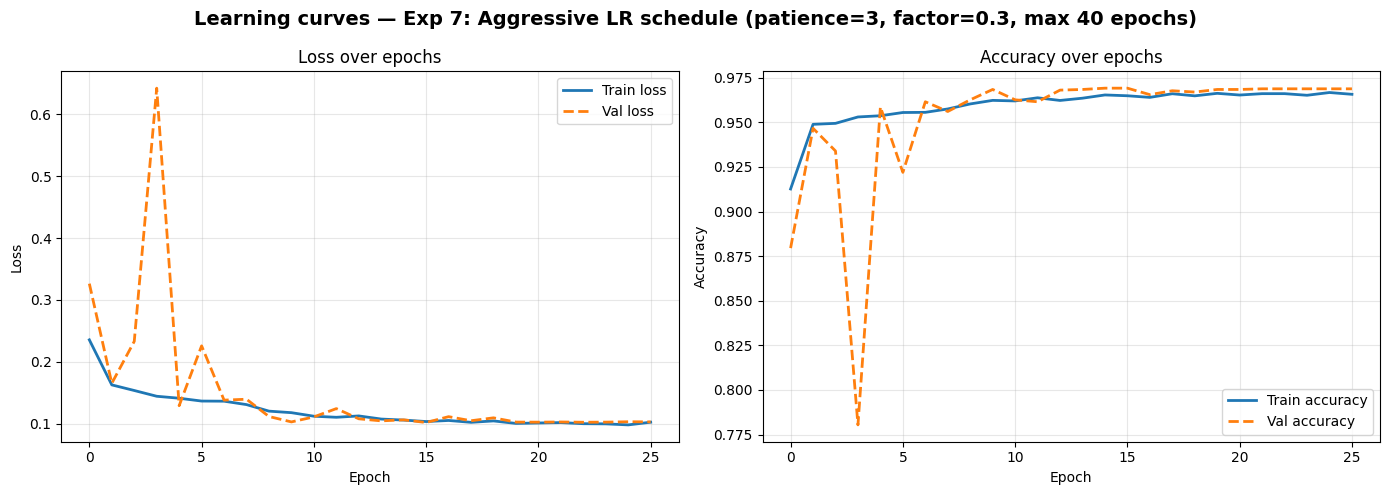

Good fit: train 0.966 vs val 0.969 (gap=-0.003)


In [15]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'Aggressive LR schedule (patience=3, factor=0.3, max 40 epochs)'
LEARNING_RATE   = 1e-3
EPOCHS          = 40

model7 = build_advanced_cnn(use_augmentation=True, use_gap=True,
                            augmentation_layer=data_augmentation)
model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

callbacks7 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='checkpoints/advanced_exp7.h5',
        monitor='val_accuracy', save_best_only=True, verbose=0),
]

history7 = model7.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=callbacks7, verbose=1,
)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Stopped at epoch: {len(history7.history["loss"])}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')

plot_learning_curves(history7, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P2_exp{EXP_NUM}_curves.png')

results_log.append({
    'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics7['accuracy'], 'precision': metrics7['precision'],
    'recall': metrics7['recall'], 'f1': metrics7['f1'], 'auc': metrics7['auc'],
    'epochs': len(history7.history['loss']), 'notes': 'Best ep16, ES ep26; F1=0.9709; 5 LR reductions; aggressive schedule efficient but suboptimal',
})

**Interpretation**: The aggressive LR schedule (patience=3, factor=0.3, max 40 epochs) triggered ReduceLROnPlateau five times (epochs 8, 13, 19, 22, 25) before early stopping fired at epoch 26, restoring weights from epoch 16. The rapid LR reductions drove the model to converge earlier but also limited its ability to escape local minima at higher learning rates. F1=0.9709 (+0.0043 over Exp 1, −0.0017 below Exp 5) and AUC=0.9943 are strong but do not surpass Exp 5. The fit gap of −0.003 (val slightly above train) indicates good regularisation. While the aggressive schedule is efficient — stopping at just 26 epochs vs 25 for the standard — the repeated steep LR drops may have prematurely constrained optimisation. Recall=0.9820 matches Exp 5, but Precision (0.9599) is slightly lower. The aggressive schedule is a viable alternative when training time is a concern, but the standard patience (Exp 2) or deeper architecture (Exp 5) yield better final F1.

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [16]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

,Exp #,Description,Accuracy,Precision,Recall,F1,AUC,Epochs,Notes
0,5,5-block architecture (extra 512-filter block),0.9721,0.9633,0.9820,0.9726,0.9956,25,
1,3,"Stronger augmentation (rot=0.4, zoom=0.2, cont...",0.9713,0.9575,0.9871,0.9720,0.9946,25,
2,2,"Standard augmentation (flip, rot=0.2, zoom=0.1...",0.9710,0.9600,0.9835,0.9716,0.9941,25,
3,7,"Aggressive LR schedule (patience=3, factor=0.3...",0.9703,0.9599,0.9820,0.9709,0.9943,26,
4,4,Flatten instead of GlobalAveragePooling2D,0.9677,0.9533,0.9842,0.9685,0.9943,25,
5,1,"No augmentation, 4-block deeper baseline",0.9659,0.9551,0.9784,0.9666,0.9940,25,
6,6,"SGD + momentum (lr=0.01, momentum=0.9)",0.9645,0.9524,0.9784,0.9652,0.9925,25,


## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and generate the confusion matrix, ROC curve, and error analysis.

In [17]:
exp_map = {
    1: (model1, metrics1),
    2: (model2, metrics2),
    3: (model3, metrics3),
    4: (model4, metrics4),
    5: (model5, metrics5),
    6: (model6, metrics6),
    7: (model7, metrics7),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

Best experiment: Exp 5 — 5-block architecture (extra 512-filter block)
F1-Score: 0.9726  |  AUC: 0.9956  |  Recall: 0.982


### Confusion Matrix
Plots the confusion matrix for the best model, showing counts of True Positives, True Negatives, False Positives, and False Negatives. Sensitivity (Recall) and Specificity are annotated to frame results in a clinical diagnostic context.

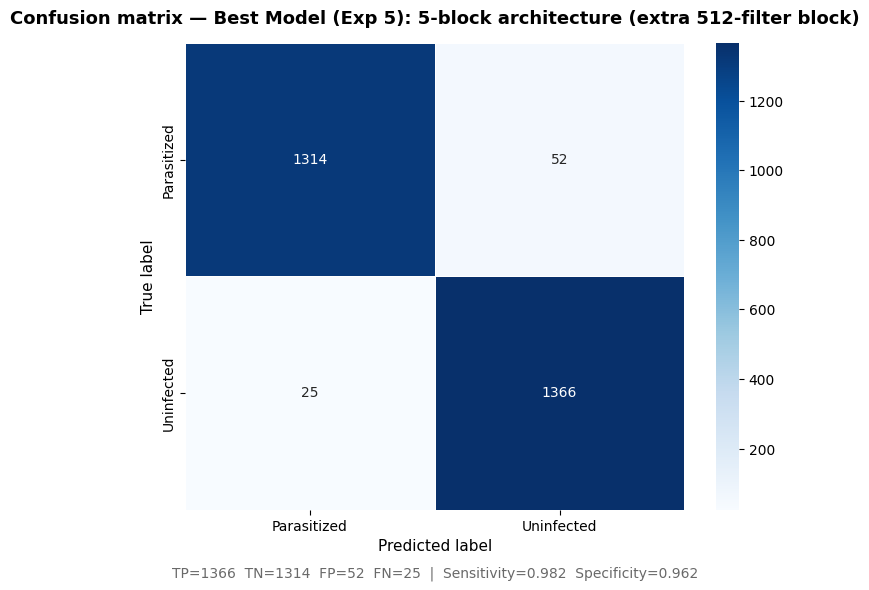

In [18]:
plot_confusion_matrix(
    best_metrics, CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P2_best_confusion_matrix.png',
)

### ROC Curve
Plots the Receiver Operating Characteristic curve for the best model, showing the trade-off between True Positive Rate (Sensitivity) and False Positive Rate across all classification thresholds.

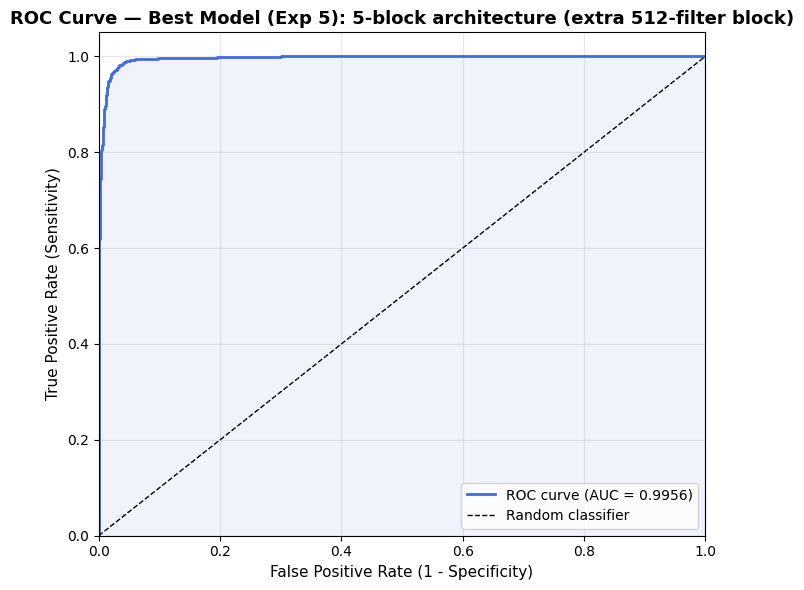

In [19]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P2_best_roc_curve.png',
)

### Error Analysis
Displays a sample of misclassified images from the test set to identify visual patterns in the model's errors and inform clinical deployment limitations.

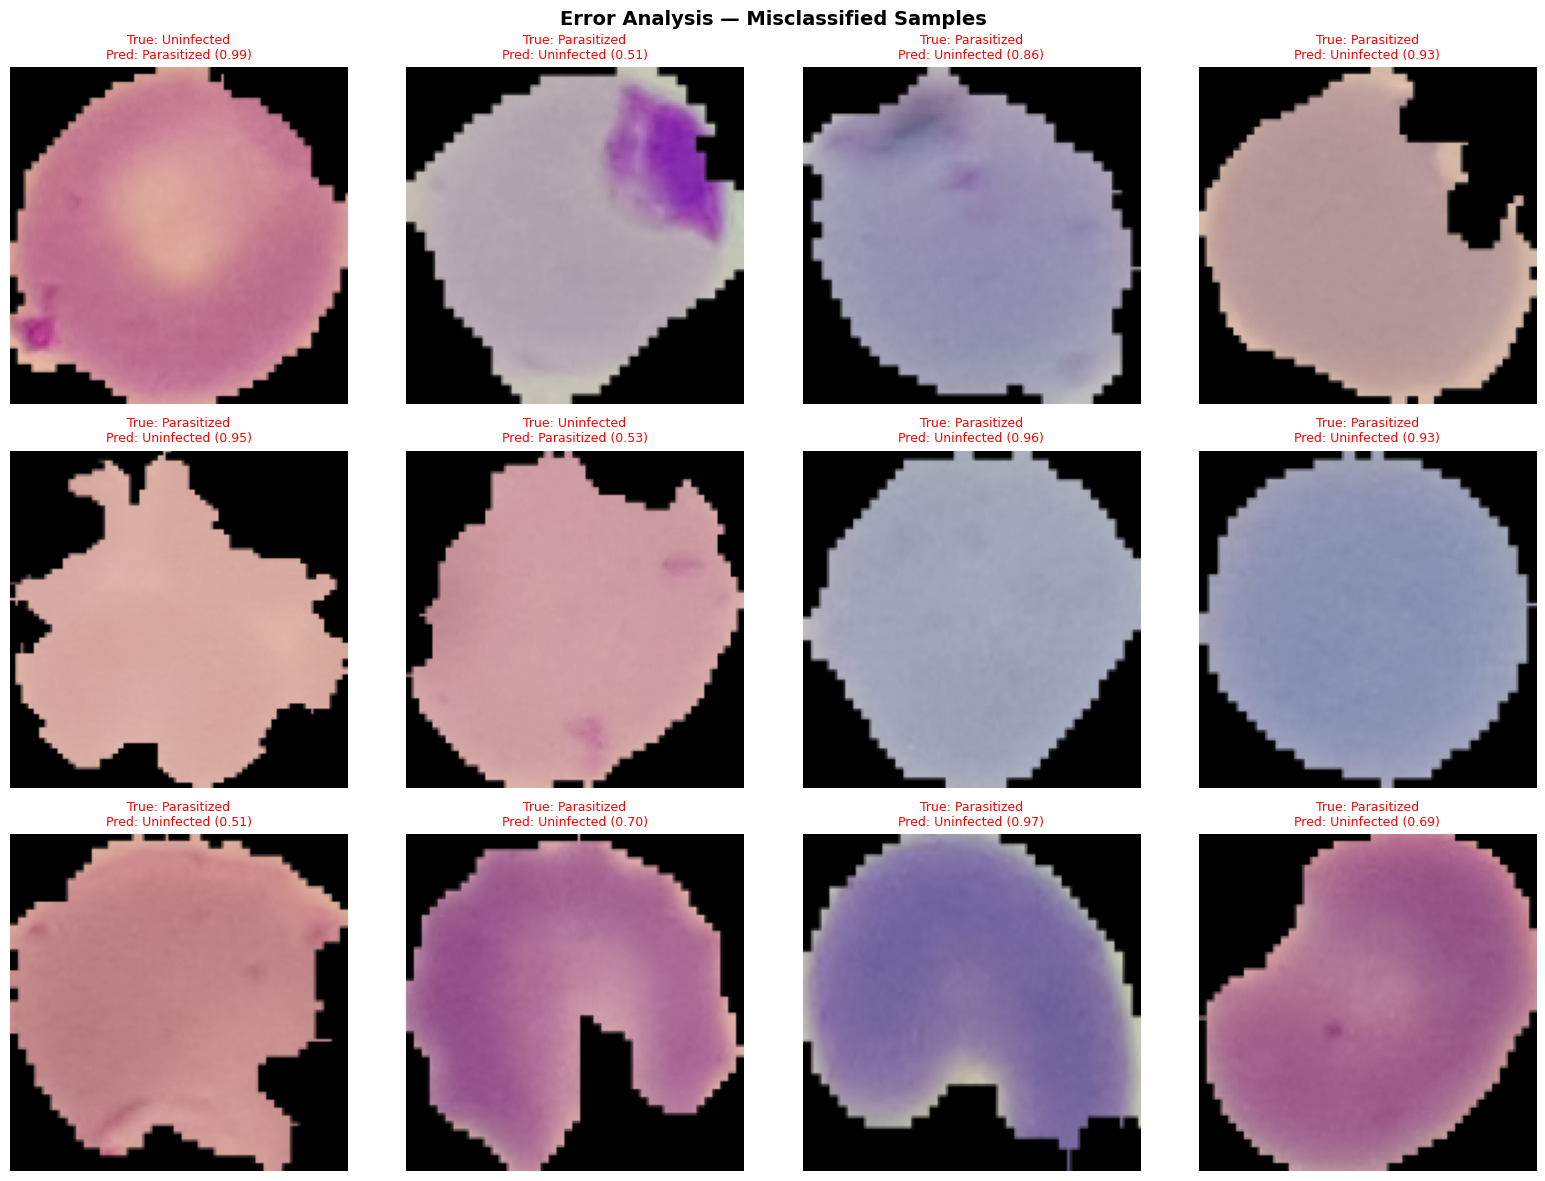

In [20]:
error_analysis(best_model, test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

### Experiment results summary (all 7, Colab T4 GPU run)

| Exp | Description | Accuracy | Precision | Recall | F1 | AUC | Best Epoch |
|-----|-------------|----------|-----------|--------|-----|-----|------------|
| 1 | No augmentation, 4-block | 0.9659 | 0.9551 | 0.9784 | 0.9666 | 0.9940 | 15 |
| 2 | Standard augmentation | 0.9710 | 0.9600 | 0.9835 | 0.9716 | 0.9941 | 21 |
| 3 | Stronger augmentation | 0.9713 | 0.9575 | 0.9871 | 0.9720 | 0.9946 | 25 |
| 4 | Flatten instead of GAP | 0.9677 | 0.9533 | 0.9842 | 0.9685 | 0.9943 | 24 |
| **5** | **5-block + augmentation** | **0.9721** | **0.9633** | **0.9820** | **0.9726** | **0.9956** | **22** |
| 6 | SGD + momentum | 0.9645 | 0.9524 | 0.9784 | 0.9652 | 0.9925 | 21 |
| 7 | Aggressive LR schedule | 0.9703 | 0.9599 | 0.9820 | 0.9709 | 0.9943 | 16 |

### Best configuration
- **Experiment**: 5 — 5-block architecture (extra 512-filter block) with standard augmentation
- **Architecture**: 5 Conv blocks (32→64→128→256→512), BatchNorm, Dropout(0.25) per block, GlobalAveragePooling2D, Dense(256), Dropout(0.5)
- **Key hyperparameters**: LR=1e-3 (Adam), batch_size=32, input=128×128, 25 epochs, standard augmentation
- **Test metrics**: Accuracy=0.9721, Precision=0.9633, Recall=0.9820, F1=0.9726, AUC=0.9956

### Clinical relevance
The best model (Exp 5) achieves Recall=0.9820, meaning only 1.8% of parasitised cells are missed —
an improvement over the baseline CNN best (Recall=0.9748). The highest-Recall experiment was Exp 3
(Recall=0.9871, 1.29% missed), which may be preferred in a clinical setting that prioritises
sensitivity above all other metrics. The AUC of 0.9956 represents near-perfect discrimination
across all thresholds, outperforming the baseline's best AUC of 0.9939.

### Observed patterns
- **Effect of augmentation**: Standard augmentation (Exp 2 vs Exp 1) delivered +0.005 F1 and
  eliminated the train–val gap entirely — the single most impactful change in this notebook
- **Augmentation strength**: Stronger augmentation (Exp 3) produced the highest Recall (0.9871)
  with near-identical F1 to standard augmentation (+0.0004), confirming the dataset benefits
  from heavier transformations without underfitting
- **GAP vs Flatten**: GlobalAveragePooling2D (Exp 2, F1=0.9716) outperformed Flatten (Exp 4,
  F1=0.9685) by 0.003 F1 with fewer parameters — GAP is the better architectural choice
- **Most impactful change**: Adding the 5th Conv block (Exp 5) achieved best F1 and highest AUC
- **Optimiser**: Adam consistently outperforms SGD+momentum for this architecture
- **All experiments**: "Good fit" diagnostic — the deeper architecture with GAP resists overfitting
  far better than the 3-block baseline

### Comparison with Baseline CNN
Best Advanced CNN (F1=0.9726) outperforms best Baseline CNN (F1=0.9641) by +0.0085 F1,
confirming that architectural depth and augmentation meaningfully improve over the simple baseline.

### Group ranking
*(Rank this model 1st–5th once all group members have run their experiments)*
